# Libraries


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [18]:
# Load the datasets
red_path= "wine+quality/winequality-red.csv"
white_path = "wine+quality/winequality-white.csv"

red_wine = pd.read_csv(red_path, sep=';')
white_wine = pd.read_csv(white_path, sep=';')
# Combine the datasets and add a 'type' column
red_wine['type'] = 0  # Red wine labeled as 0
white_wine['type'] = 1  # White wine labeled as 1
wine_data = pd.concat([red_wine, white_wine], ignore_index=True)
# Display basic information about the dataset
print(wine_data.info())


<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB
None


# EDA

In [19]:
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


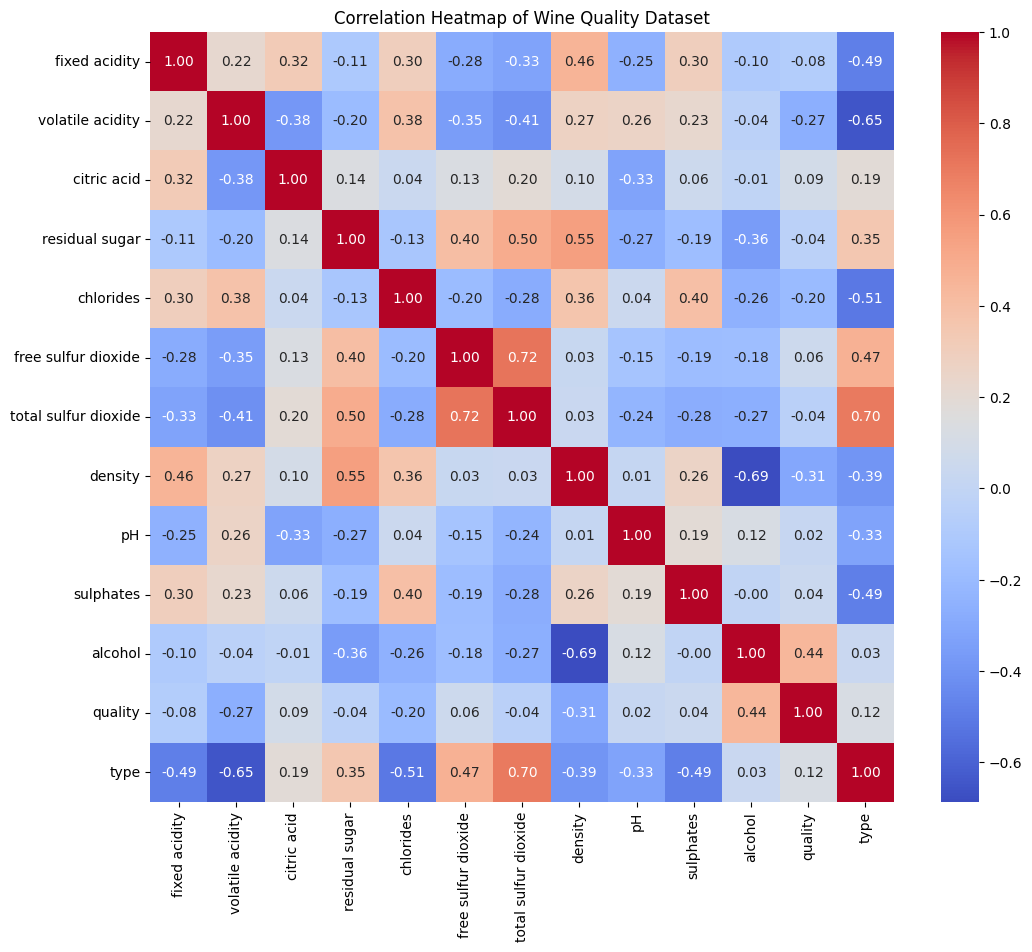

In [20]:
# Heat map of correlations
plt.figure(figsize=(12, 10))
sns.heatmap(wine_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Wine Quality Dataset')
plt.show()

# Model Train

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

# Features and target
X = wine_data.drop('quality', axis=1)
y = (wine_data['quality'] >= 5).astype(int)  # binary classification: good (1) vs bad (0)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40
)

# Model
model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)
feature_columns = X.columns

# Predict
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.64      0.20      0.30        46
           1       0.97      1.00      0.98      1254

    accuracy                           0.97      1300
   macro avg       0.81      0.60      0.64      1300
weighted avg       0.96      0.97      0.96      1300



# Test

In [36]:
# Try a new prediction
new_wine = pd.DataFrame([[ 
    7.0,   # fixed acidity
    0.27,  # volatile acidity
    0.36,  # citric acid
    20.7,  # residual sugar
    0.045, # chlorides
    45.0,  # free sulfur dioxide
    170.0, # total sulfur dioxide
    1.001, # density
    3.0,   # pH
    0.45,  # sulphates
    8.8,   # alcohol
    1      # type (1 for white, 0 for red)
]], columns=feature_columns)

prediction = model.predict(new_wine)
print("Predicted quality (1=good, 0=bad):", prediction[0])


Predicted quality (1=good, 0=bad): 1


# Save the model

In [ ]:
# Save the model using joblib
import joblib
joblib.dump(model, 'wine_quality_model.joblib')


['wine_quality_model.joblib']